# LLM usage for baking: an evaluation on ratio-sensitive recipes
<!-- 2026-09-07 -->

## Background

Outside of work, one of my most frequent usages of LLMs is while I am cooking. I don't like to waste food, so I frequently have meals whose inspiration is "these cans are past their expiration date and I have carrots in the fridge that look questionable". I find that LLMs can usually give good suggestions in these situations, and I've talked to others with similar experiences. In fact, [about 1% of ChatGPT conversations](https://www.restaurantbusinessonline.com/ai-menus-partnered-content-series/chatgpt-will-almost-feed-you-now) are related to cooking and ingredients.

However, given the adage that "cooking is an art, but baking is a science", I was curious about whether my LLM-assisted cooking could extend to recipes with tighter ingredient quantities. If I'm adding salt while cooking, I can taste halfway through so I don't put too much, but you can't do that when you're baking a pie crust or making bread. 

In this post I'm going to explore:
* Can you rely on ChatGPT to give you reliable quantities for baking?
* Does asking for a "foolproof" recipe increase ingredient quantity accuracy?
* If you are cooking for a crowd, can you ask the LLM for a large quantity or should you ask for a normal quantity and scale up/down manually?

## Experimental setup

### Model selection

I used GPT 5-6 Luna for this comparison. I did this for a few reasons: 
* I generated a couple of recipes using the ChatGPT app, and one of them used GPT 5-6 Luna so I'm confident that some people are getting their recipes from GPT 5-6 Luna
* GPT 5-6 Luna is really cheap and I had some credits left in my OpenAI account
* I considered using Claude for this comparison, but when you use the Claude app to generate a recipe, it uses a tool to provide you with an interface. I felt that using GPT 5-6 Luna and scoring free-text would be a good analog to what users actually experience when they generate recipes, and this approach didn't require me to reverse-engineer a tool.

### Food Selection

I chose recipes that had fairly tight tolerances on relative quantities between ingredients, because I wanted to identify clear "failures" when the LLM generated a recipe outside the bounds. 

I also chose recipes which would scale ingredients in a linear fashion. For example the yeast-to-flour ratio in a bread recipe is important, but when you double a bread recipe, you don't necessarily always have to double the yeast (at least that's what I would guess given the couple of biology classes I've taken; my wife may contend that there were some occasions with slow-rising rolls where doubling the yeast may have been helpful).

Anyway, the foods I chose to use for this experiment were:
* Pie Crust (with a sensitive fat:flour and water:flour ratio)
* Panna Cotta (with a sensitive liquid:gelatin ratio)
* Pastry Cream (with a sensitive cornstarch:dairy ratio)
* Choux Pastry (with a sensitive egg:flour ratio)

### Recipe evaluation

To assign pass/fail results to a recipe, I extracted quantities into a structured format with a second LLM call using the same model. I used a stronger model (Claude Opus 5) to evaluate ingredient quantity extraction and found 0/28 missed-or-misread ingredients, 0/28 false precision, but 2/28 (7.1%) wrong line semantics. These error rates were acceptable, so I continued with LLM extraction using GPT 5-6 Luna.

When a range was specified by a generated recipe, the model parsed both the max and min values and the scorer took the midpoint as the recipe's actual value for the purposes of ratio accuracy evaluation. If no quantities were specified (e.g. "a few") for an ingredient involved in an outcome ratio, the recipe was marked as unscorable. For some recipes, the generated recipe specified a maximum or minimum amount of an ingredient and suggested adding gradually until a consistency was met; in that situation, the stated quantity was used to calculate the ratio instead of assuming a smaller or larger value.

After ingredients were extracted, I converted them to grams, and computed ratios observed in the recipe. To determine recipes with successful ratios, I looked at results for 5-10 actual tested recipes I found on the internet. Note that for panna cotta, I found a [Seattle Times Article](https://www.seattletimes.com/life/food-drink/3-keys-to-perfect-panna-cotta/) where an author tested recipes and reported results so I used that one for the ranges. 

Here are the acceptable ranges I'm using in my analysis:

| Recipe | Ratio(s) checked | Ground truth | Basis |
|---|---|---|---|
| **Pie Crust** | fat:flour (by weight) | pass: 0.68–0.89 | Convergence across 8 independently-tested recipes |
| | water:flour (by weight) | pass: 0.28–0.50 | Same 8-recipe set. Shortening-only recipe sets the high end (shortening carries no water, so more must be added vs. butter) |
| **Panna Cotta** | gelatin:liquid (by weight %) | pass: 0.65%–3.9% | Documented range across tested/published recipes by Seattle Times (set/don't-set language).  |
| **Pastry Cream** | cornstarch:dairy (by weight %) | pass: 4.1%–8.3% | Convergence across 12 independently-tested recipes (King Arthur x2, Scotch & Scones, Sally's Baking Addiction, Allrecipes, Serious Eats, Preppy Kitchen, Martha Stewart, Stay at Home Chef, Natasha's Kitchen, Food Network, one additional source). Dense cluster ~4.8%–6.6%; King Arthur GF (4.1%) and Preppy Kitchen's richer 6-yolk version (8.3%) are the outer bounds. |
| **Choux Pastry** | egg:flour (by weight) | pass: 1.3:1–2.3:1 | Convergence across 10 independently-tested recipes (Ruhlman canonical, America's Test Kitchen, Food Network, Sally's Baking Addiction, Allrecipes, Bonni Bakery, King Arthur, The Flavor Bender, The Buttery Crust, one additional source). King Arthur's tested recipe (1.33:1) sets the low end; Bonni Bakery's own stated 5–6 egg range (1.92:1–2.31:1) sets the high end. Egg weight assumed ~50g/large egg, no shell, unless a source states shell-inclusive weight (see caveat below). |


*Note that unlike the rest of the text in this post, the above table was generated by Claude. I'm including this note to follow my [AI use policy](https://www.zacharyclement.com/about/).*


### Prompt 

I used a very simple prompt to generate recipes: 

```
Can you give me a recipe for [adjective] [requested food] [quantity modifier]?
```

In order to evaluate the effect of asking for a "foolproof" recipe, I changed `[adjective]` to be either "really tasty", "foolproof", or "avant garde".

I replaced `[requested food]` with the food I wanted a recipe generated for.

For `[quantity modifier]`, I used either a blank, 6 people (to approximate the most common usage), 35 people (to approximate the max of what a home cook might be cooking for), or 173 people (to evaluate LLM scaling in an out-of-distribution quantity).

I did not provide a system prompt or any tools to the model. 

### Sample Size

For each unique prompt, I generated 5 recipes, which led to 240 generations (4 foods, 3 adjectives, 4 serving sizes, and 5 generations). Two recipes were not scorable so they were dropped from this analysis. 


In [1]:
import pandas as pd

ip = get_ipython()
fmt = ip.display_formatter.formatters

# pandas exposes _repr_html_ rather than registering in type_printers, so
# deleting from type_printers is a no-op. Registering a printer that returns
# None is what actually suppresses the text/html mimetype.
fmt['text/html'].for_type(pd.DataFrame, lambda df: None)
fmt['text/html'].for_type(pd.Series, lambda s: None)

# Emit markdown instead, which nbconvert falls back to once html is gone.
fmt['text/markdown'].for_type(pd.DataFrame, lambda df: df.to_markdown())
fmt['text/markdown'].for_type(pd.Series, lambda s: s.to_markdown())
print("")

In [2]:
# --- One color scheme for the whole notebook. Every chart below imports from
# --- here rather than picking its own colors. ---
import matplotlib.pyplot as plt
import matplotlib as mpl

INK        = "#0b0b0b"   # titles, primary text
INK_MUTED  = "#52514e"   # axis labels, secondary text
GRID       = "#dcdbd6"   # gridlines, spines
BG         = "#fcfcfb"   # figure/axes background
BAND       = "#e7e6e2"   # shaded reference bands

# Categorical palette: one fixed color per adjective, used identically in
# every chart that breaks results out by adjective.
ADJ_COLOR = {"control": "#2a78d6", "foolproof": "#eb6834", "avant_garde": "#1baf7a"}
ADJ_MARKER = {"control": "o", "foolproof": "s", "avant_garde": "^"}
ADJ_LABEL = {"control": "really tasty (control)", "foolproof": "foolproof",
             "avant_garde": "avant garde"}

# Sequential palette (light -> dark) for the four recipes, used identically
# whenever recipes are broken out on one axis.
RECIPE_COLOR = {
    "pie_dough": "#8ab6e6",
    "panna_cotta": "#4f8fd6",
    "pastry_cream": "#2a5fa8",
    "choux": "#12305c",
}
RECIPE_LABEL = {"pie_dough": "pie crust", "panna_cotta": "panna cotta",
                 "pastry_cream": "pastry cream", "choux": "choux pastry"}

SCALE_LABEL = {"default": "unspecified", "6": "6", "35": "35", "173": "173"}

def style_axes(ax):
    ax.set_facecolor(BG)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, labelsize=9, length=0)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

def new_fig(figsize=(9, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(BG)
    style_axes(ax)
    return fig, ax

mpl.rcParams["font.size"] = 10
mpl.rcParams["text.color"] = INK
mpl.rcParams["axes.labelcolor"] = INK_MUTED

In [3]:
import json
from pathlib import Path

import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint

DATA_ROOT = Path("recipe_generation")

RECIPE_NAMES = ["pie_dough", "panna_cotta", "pastry_cream", "choux"]
ADJECTIVE_NAMES = ["control", "foolproof", "avant_garde"]
SCALE_NAMES = ["default", "6", "35", "173"]
SCALE_N = {"default": np.nan, "6": 6, "35": 35, "173": 173}

scores = pd.read_csv(DATA_ROOT / "results" / "scores.csv")
scores["abs_log2_deviation"] = scores["log2_deviation"].abs()
scores["adjective"] = pd.Categorical(scores["adjective"], ADJECTIVE_NAMES, ordered=True)
scores["scale"] = pd.Categorical(scores["scale"], SCALE_NAMES, ordered=True)
scores["recipe"] = pd.Categorical(scores["recipe"], RECIPE_NAMES, ordered=True)

per_gen = pd.read_csv(DATA_ROOT / "results" / "per_generation.csv")
per_gen["adjective"] = pd.Categorical(per_gen["adjective"], ADJECTIVE_NAMES, ordered=True)
per_gen["scale"] = pd.Categorical(per_gen["scale"], SCALE_NAMES, ordered=True)
per_gen["recipe"] = pd.Categorical(per_gen["recipe"], RECIPE_NAMES, ordered=True)


### Example Generation

Here's an example of one of the recipes generated, how ingredients were extracted, and results.



In [4]:
def _condition_dir(recipe, adjective, scale):
    return DATA_ROOT / "data" / f"{recipe}__{adjective}__{scale}"

def _read_manifest(cdir):
    import csv
    with open(cdir / "manifest.csv", newline="") as f:
        return {int(row["repeat_index"]): row for row in csv.DictReader(f)}

def show_example(recipe="choux", adjective="avant_garde", scale="173", repeat_index=0):
    '''Print the prompt, full generated recipe, extracted ingredient table,
    and final ratio score for one (recipe, adjective, scale, repeat) cell.

    Example: show_example("pie_dough", "foolproof", "35", repeat_index=2)
    '''
    cdir = _condition_dir(recipe, adjective, scale)
    manifest = _read_manifest(cdir)
    if repeat_index not in manifest:
        raise KeyError(f"no repeat {repeat_index} in {cdir.name}; have {sorted(manifest)}")
    h = manifest[repeat_index]["hash"]

    gen = json.loads((cdir / f"{h}.generation.json").read_text())
    extraction = json.loads((cdir / f"{h}.extraction.json").read_text())
    score = json.loads((cdir / f"{h}.score.json").read_text())

    print("=" * 78)
    print(f"CONDITION   {RECIPE_LABEL[recipe]} | {ADJ_LABEL[adjective]} | "
          f"serving size: {SCALE_LABEL[scale]} | repeat {repeat_index}")
    print(f"PROMPT      {gen['prompt']!r}")
    print("=" * 78)

    print("\n--- 1. Generated recipe (verbatim model response) ---\n")
    print(gen["response_text"])

    print("\n--- 2. Extracted ingredient lines ---\n")
    ing = pd.DataFrame(extraction["extraction"]["ingredients"])
    cols = ["name", "quantity", "quantity_low", "quantity_high", "unit",
            "component", "is_core", "option_group", "is_default_option"]
    display(ing[[c for c in cols if c in ing.columns]])

    print("\n--- 3. Scored ratio(s) ---\n")
    for ratio_name, r in score["ratios"].items():
        unit = "%" if r["as_percent"] else ""
        verdict = "PASS" if r["passed"] else "FAIL"
        print(f"  {ratio_name}: {r['numerator']} / {r['denominator']} = "
              f"{r['value']:.4g}{unit}  "
              f"(band {r['band_low']}-{r['band_high']}{unit}, "
              f"center {r['band_center']}{unit})  -> {verdict}")
    print(f"\n  recipe-level verdict: {'PASS' if score['passed'] else 'FAIL'}")


show_example("choux", "foolproof", "6", repeat_index=1)

CONDITION   choux pastry | foolproof | serving size: 6 | repeat 1
PROMPT      'Can you give me a recipe for foolproof choux pastry for 6 people?'

--- 1. Generated recipe (verbatim model response) ---

## Foolproof choux pastry for 6

Makes about **12–15 small profiteroles** or **6–8 éclairs**.

### Ingredients
- 125 ml water  
- 60 g unsalted butter, cubed  
- ¼ tsp salt  
- 1 tsp sugar — optional, useful for sweet choux  
- 75 g plain/all-purpose flour, sifted  
- 2–3 large eggs, lightly beaten — about **100–120 g without shells**

### Method

1. **Prepare the oven and tray**  
   Heat the oven to **200°C conventional / 180°C fan**. Line a baking tray with parchment.

2. **Boil the butter mixture**  
   Put the water, butter, salt and sugar in a saucepan over medium heat. Heat until the butter has melted and the mixture reaches a full boil.

3. **Add the flour all at once**  
   Remove the pan from the heat and tip in the flour immediately. Stir vigorously with a wooden spoon until s

|    | name                            |   quantity |   quantity_low |   quantity_high | unit   | component    | is_core   | option_group   | is_default_option   |
|---:|:--------------------------------|-----------:|---------------:|----------------:|:-------|:-------------|:----------|:---------------|:--------------------|
|  0 | water                           |     125    |            nan |             nan | ml     | choux pastry | True      |                | False               |
|  1 | unsalted butter, cubed          |      60    |            nan |             nan | g      | choux pastry | True      |                | False               |
|  2 | salt                            |       0.25 |            nan |             nan | tsp    | choux pastry | True      |                | False               |
|  3 | sugar                           |       1    |            nan |             nan | tsp    | choux pastry | True      |                | False               |
|  4 | plain/all-purpose flour, sifted |      75    |            nan |             nan | g      | choux pastry | True      |                | False               |
|  5 | eggs, lightly beaten            |     nan    |            100 |             120 | g      | choux pastry | True      |                | False               |


--- 3. Scored ratio(s) ---

  egg_to_flour: egg / flour = 1.467  (band 1.3-2.3, center 1.7999999999999998)  -> PASS

  recipe-level verdict: PASS


## Can you rely on ChatGPT to give you reliable quantities for baking?

I think that most people using ChatGPT for cooking want to know: "If I ask ChatGPT for a pie crust recipe is it going to fall apart?" So, for each recipe I evaluated whether it fell within the acceptable recipe ranges. 


In [5]:
scores["recipe_ratio"] = scores["recipe"].astype(str) + " / " + scores["ratio"]

rp = per_gen[per_gen["recipe_passed"].notna()].copy()
rp["recipe_passed_int"] = rp["recipe_passed"].astype(int)

fail = (
    rp.groupby("recipe", observed=True)["recipe_passed_int"]
    .agg(n="size", n_pass="sum")
    .reset_index()
)
fail["n_fail"] = fail["n"] - fail["n_pass"]

fail = fail.set_index("recipe").loc[RECIPE_NAMES].reset_index()
fail["fail_rate"] = fail["n_fail"] / fail["n"]
ci = fail.apply(lambda r: proportion_confint(r["n_fail"], r["n"], method="wilson"), axis=1)
fail["ci_low"], fail["ci_high"] = zip(*ci)
df_to_print = fail.loc[:, ["recipe", "n", "fail_rate"]].rename({"recipe": "Recipe", "n": "# Generated and Parsed", 
                                "fail_rate": "% failures"}, axis = 1)
df_to_print["Recipe"] = df_to_print["Recipe"].apply(lambda x: x.replace("dough", "crust").replace("_", " ").title())
display(df_to_print.set_index("Recipe"))

        

| Recipe       |   # Generated and Parsed |   % failures |
|:-------------|-------------------------:|-------------:|
| Pie Crust    |                       59 |    0.389831  |
| Panna Cotta  |                       59 |    0.0338983 |
| Pastry Cream |                       60 |    0         |
| Choux        |                       60 |    0.0166667 |

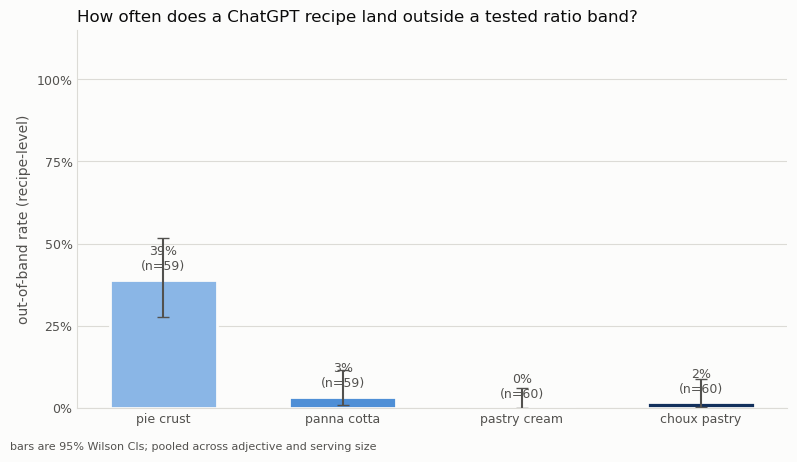

In [6]:


fig, ax = new_fig((8, 4.6))
x = range(len(RECIPE_NAMES))
bars = ax.bar(
    x, fail["fail_rate"],
    color=[RECIPE_COLOR[r] for r in RECIPE_NAMES],
    width=0.6, edgecolor=BG, linewidth=2,
    yerr=[fail["fail_rate"] - fail["ci_low"], fail["ci_high"] - fail["fail_rate"]],
    ecolor=INK_MUTED, capsize=4,
)
for i, row in fail.iterrows():
    ax.text(i, row["fail_rate"] + 0.03, f"{row['fail_rate']:.0%}\n(n={row['n']})",
            ha="center", fontsize=9, color=INK_MUTED)
ax.set_xticks(list(x))
ax.set_xticklabels([RECIPE_LABEL[r] for r in RECIPE_NAMES])
ax.set_ylim(0, 1.15)
ax.set_yticks([0, .25, .5, .75, 1.0]); ax.set_yticklabels(["0%","25%","50%","75%","100%"])
ax.set_ylabel("out-of-band rate (recipe-level)")
ax.set_title("How often does a ChatGPT recipe land outside a tested ratio band?",
             color=INK, fontsize=12, loc="left")
fig.text(0.01, 0.01, "bars are 95% Wilson CIs; pooled across adjective and serving size",
          color=INK_MUTED, fontsize=8)
fig.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

ChatGPT produced recipes with ingredient ratios outside of the acceptable tolerances 39% of the time for the most commonly-baked recipe here (Pie Crust) and 11% of the time overall. Although my baking failures are more frequently of the "forgot to set a timer and now the fire alarm is going off" variety rather than "too much fat content in my dough" variety, it still seems like I might be better off avoiding injecting additional variation in the end results from an unstable recipe. 

Note that the 11% number is probably not a good estimate of how often recipe generation will fail in the real world. Because failure rates vary widely by food type, and we only included four food types, I would expect a very different number if we were to randomly sample a large number across a larger variety of food types. 

## Does asking for a "foolproof" recipe increase ingredient quantity accuracy?

If ChatGPT is not super reliable at generating recipes, are there low-effort things that users can do to make it more reliable? The space of low-effort things to do is pretty small because the alternative of just looking up a recipe blog is pretty easy, but I was curious if asking for a "foolproof" recipe would pull the quantities within the distribution.

In [7]:
by_adj = (
    rp.groupby(["recipe", "adjective"], observed=True)
    .agg(n=("recipe_passed_int", "size"),
         fail_rate=("recipe_passed_int", lambda s: 1 - s.mean()),
         mean_abs_dev=("mean_abs_dev", "mean"))
    .reset_index()
)


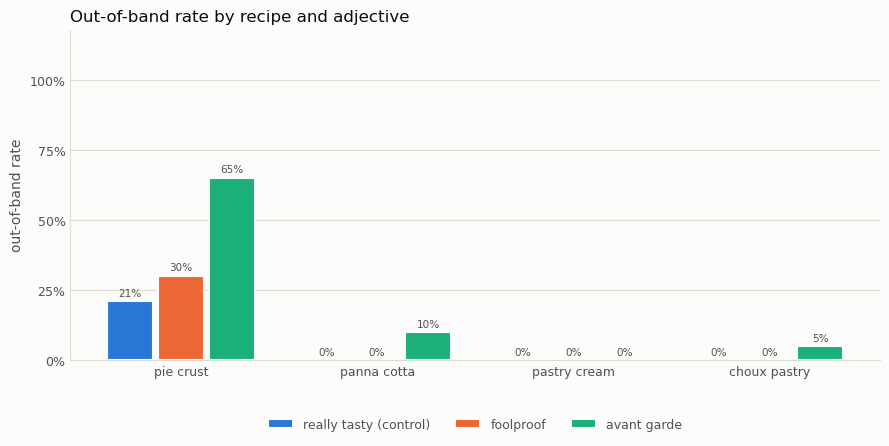

In [8]:
fig, ax = new_fig((9, 4.6))
width = 0.26
x = range(len(RECIPE_NAMES))
for offset, adj in zip((-width, 0, width), ADJECTIVE_NAMES):
    rates = [by_adj.query("recipe == @r and adjective == @adj")["fail_rate"].pipe(
                lambda s: s.iloc[0] if len(s) else float("nan")) for r in RECIPE_NAMES]
    pos = [i + offset for i in x]
    bars = ax.bar(pos, rates, width * 0.9, color=ADJ_COLOR[adj], label=ADJ_LABEL[adj],
                  edgecolor=BG, linewidth=1.5)
    for b, rate in zip(bars, rates):
        if rate == rate:
            ax.text(b.get_x() + b.get_width() / 2, rate + 0.02, f"{rate:.0%}",
                    ha="center", fontsize=7.5, color=INK_MUTED)
ax.set_xticks(list(x)); ax.set_xticklabels([RECIPE_LABEL[r] for r in RECIPE_NAMES])
ax.set_ylim(0, 1.18); ax.set_yticks([0, .25, .5, .75, 1.0])
ax.set_yticklabels(["0%","25%","50%","75%","100%"])
ax.set_ylabel("out-of-band rate")
ax.set_title('Out-of-band rate by recipe and adjective', color=INK, fontsize=12, loc="left")
ax.legend(frameon=False, fontsize=9, labelcolor=INK_MUTED, ncol=3,
          loc="upper center", bbox_to_anchor=(0.5, -0.14))
fig.tight_layout()
plt.show()

In [9]:
# Statistical model

df_for_logreg = rp.loc[rp.recipe != 'pastry_cream', :].copy()
df_for_logreg.recipe = df_for_logreg.recipe.astype(str)
adj_model = smf.logit("recipe_passed_int ~ C(recipe) + C(adjective, Treatment(reference='control'))", 
                      data=df_for_logreg).fit()
print(adj_model.summary())
print("==============================================================================\n\n")
print("Results comparing C(adjective, Treatment(reference='control'))[T.avant_garde]  and C(adjective, Treatment(reference='control'))[T.foolproof]")

print(adj_model.t_test(
    "C(adjective, Treatment(reference='control'))[T.avant_garde] - C(adjective, Treatment(reference='control'))[T.foolproof] = 0"
))


Optimization terminated successfully.
         Current function value: 0.260143
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:      recipe_passed_int   No. Observations:                  178
Model:                          Logit   Df Residuals:                      173
Method:                           MLE   Df Model:                            4
Date:                Mon, 07 Sep 2026   Pseudo R-squ.:                  0.3744
Time:                        17:03:06   Log-Likelihood:                -46.305
converged:                       True   LL-Null:                       -74.017
Covariance Type:            nonrobust   LLR p-value:                 2.649e-11
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------
Intercept 

*Note: I excluded pastry cream from this model because there were no failures*

From my analysis, it doesn't look like asking for a "foolproof" recipe reduces out-of-band ingredient ratios vs the "really tasty" control. It may be that more rigorous prompting, extended reasoning, or custom tool use can reduce out-of-band occurrence, but again, all of those are getting into the "more difficult than scrolling through a recipe blogger's story about why they love this recipe" territory. 

However, it does look like asking for an "avant-garde" recipe does increase the risk of a bad recipe generation (both against the "foolproof" and "really tasty" adjective). So, it may be wise to avoid using that language if you are prompting for recipes and want a recipe that works. 

## If you are cooking for a crowd, can you ask the LLM for a large quantity or should you ask for a normal quantity and scale up/down manually?

When you're cooking for more than a couple of people, you can do one of two things: 
1. Ask for a recipe, look at the quantities given, then double/triple the recipe in your head as needed
2. Tell an LLM exactly how many people you are cooking for and bake based on the response.

In theory, the first strategy (i.e. requesting a recipe for 6 people and multiplying by 6) should give you the same quantity of ingredients as the second (i.e. requesting a recipe for 36 people directly). However, the second strategy might go wrong because LLMs [cannot natively do arithmetic](https://arxiv.org/html/2504.05262v2) and need a tool to reliably add or multiply. So, unless the quantity you are asking for is something that was seen in its training distribution, there is a risk of the ingredient quantities falling out of sync with each other, or of the quantities needed being incorrect for the number of mouths the recipe needs to feed. 


### Are ratios self-consistent at low or large serving sizes? 


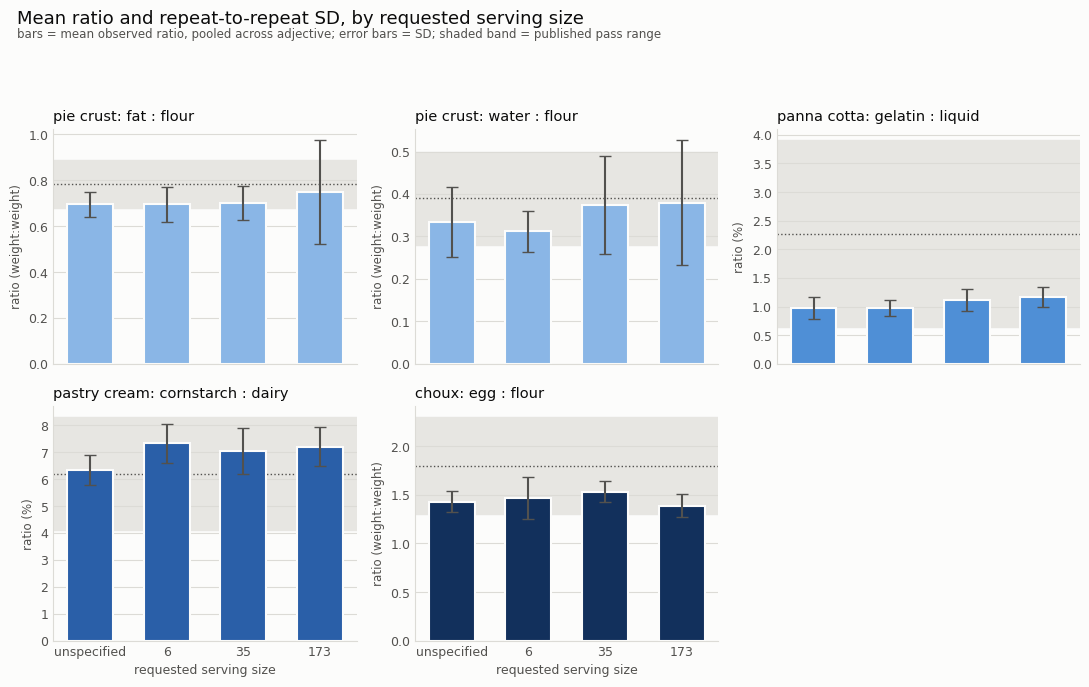

In [10]:
scored_all = scores[scores["value"].notna()]

RATIO_ORDER = [
    ("pie_dough", "fat_to_flour"),
    ("pie_dough", "water_to_flour"),
    ("panna_cotta", "gelatin_to_liquid"),
    ("pastry_cream", "cornstarch_to_dairy"),
    ("choux", "egg_to_flour"),
]
RATIO_TITLE = {
    ("pie_dough", "fat_to_flour"): "pie crust: fat : flour",
    ("pie_dough", "water_to_flour"): "pie crust: water : flour",
    ("panna_cotta", "gelatin_to_liquid"): "panna cotta: gelatin : liquid",
    ("pastry_cream", "cornstarch_to_dairy"): "pastry cream: cornstarch : dairy",
    ("choux", "egg_to_flour"): "choux: egg : flour",
}
RATIO_AS_PCT = {
    ("pie_dough", "fat_to_flour"): False,
    ("pie_dough", "water_to_flour"): False,
    ("panna_cotta", "gelatin_to_liquid"): True,
    ("pastry_cream", "cornstarch_to_dairy"): True,
    ("choux", "egg_to_flour"): False,
}

# Pool across adjective and repeats -- one bar per (recipe/ratio, scale),
# height = mean observed ratio, error bar = SD across those generations.
bar_stats = (
    scored_all.groupby(["recipe", "ratio", "scale"], observed=True)["value"]
    .agg(mean="mean", sd="std", n="count")
    .reset_index()
)

fig, axes = plt.subplots(2, 3, figsize=(11, 7), sharex=True)
fig.patch.set_facecolor(BG)
axes.flat[-1].set_visible(False)

for ax, (recipe, ratio) in zip(axes.flat, RATIO_ORDER):
    style_axes(ax)
    sub = bar_stats[(bar_stats["recipe"] == recipe) & (bar_stats["ratio"] == ratio)]
    sub = sub.set_index("scale").reindex(SCALE_NAMES)
    band_row = scored_all[(scored_all["recipe"] == recipe) & (scored_all["ratio"] == ratio)].iloc[0]
    band_low, band_high = band_row["band_low"], band_row["band_high"]

    ax.axhspan(band_low, band_high, color=BAND, zorder=0)
    ax.axhline((band_low + band_high) / 2, color=INK_MUTED, linewidth=1, linestyle=":")

    xpos = range(len(SCALE_NAMES))
    ax.bar(xpos, sub["mean"], width=0.6, color=RECIPE_COLOR[recipe],
           edgecolor=BG, linewidth=1.5,
           yerr=sub["sd"], ecolor=INK_MUTED, capsize=4, zorder=2)

    ax.set_title(RATIO_TITLE[(recipe, ratio)], color=INK, fontsize=10.5, loc="left")
    ax.set_xticks(list(xpos))
    ax.set_xticklabels([SCALE_LABEL[s] for s in SCALE_NAMES])
    unit = "%" if RATIO_AS_PCT[(recipe, ratio)] else ""
    ax.set_ylabel(f"ratio ({unit or 'weight:weight'})", fontsize=8.5)

for ax in axes[-1]:
    ax.set_xlabel("requested serving size", fontsize=9)

fig.suptitle("Mean ratio and repeat-to-repeat SD, by requested serving size",
             color=INK, fontsize=13, x=0.02, y=0.995, ha="left")
fig.text(0.02, 0.955,
          "bars = mean observed ratio, pooled across adjective; "
          "error bars = SD; shaded band = published pass range",
          color=INK_MUTED, fontsize=8.5, ha="left")
fig.tight_layout(rect=(0, 0.02, 1, 0.92))
plt.show()

Higher scales did lead to higher variability in reported ratios in some cases, but it was not consistent across all recipes. I was somewhat surprised--I expected that at a recipe size of 173, the LLM generation would be less stable and substantially more likely to produce bad ratios.

Anyway, here's a linear model testing this statistically. Pie crust (the reference condition) had significantly more variability in its generated ratios at higher scales, but Choux Pastry had a significant interaction in the other direction.

In [11]:
cell_sd = (
    scored_all.groupby(["recipe", "ratio", "adjective", "scale"], observed=True)
    ["log2_deviation"].agg(sd="std", n="count").reset_index()
)
cell_sd["scale_n"] = cell_sd["scale"].map(SCALE_N)
cell_sd_numeric = cell_sd[cell_sd["scale"] != "default"].dropna(subset=["sd"]).copy()
cell_sd_numeric["log10_scale_n"] = np.log10(cell_sd_numeric["scale_n"])

noise_model = smf.ols("sd ~ log10_scale_n * C(recipe)", data=cell_sd_numeric).fit()
print(noise_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     sd   R-squared:                       0.367
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     3.062
Date:                Mon, 07 Sep 2026   Prob (F-statistic):             0.0120
Time:                        17:03:08   Log-Likelihood:                 29.346
No. Observations:                  45   AIC:                            -42.69
Df Residuals:                      37   BIC:                            -28.24
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

### Do ingredient quantities scale reliably or should you multiply from a low-scale recipe to ensure correct outcome quantity? 

In [12]:
# Pull the raw gram quantities behind each ratio (not just the ratio itself)
# out of the per-generation score files, for every core ratio ingredient
# across all four recipes.
RATIO_INGREDIENTS = [
    ("pie_dough", "fat_to_flour", "fat", "flour"),
    ("pie_dough", "water_to_flour", "water", "flour"),
    ("panna_cotta", "gelatin_to_liquid", "gelatin", "liquid"),
    ("pastry_cream", "cornstarch_to_dairy", "cornstarch", "dairy"),
    ("choux", "egg_to_flour", "egg", "flour"),
]
QUANTITY_SCALES = ["6", "35", "173"]

quantity_rows = []
seen_denominator = set()  # avoid double-counting flour from two pie-dough ratios
for recipe, ratio, num_name, den_name in RATIO_INGREDIENTS:
    for adjective in ADJECTIVE_NAMES:
        for scale in QUANTITY_SCALES:
            cdir = _condition_dir(recipe, adjective, scale)
            if not cdir.exists():
                continue
            for f in cdir.glob("*.score.json"):
                score = json.loads(f.read_text())
                r = score.get("ratios", {}).get(ratio)
                if not r:
                    continue
                key = (f, den_name)
                ng, dg = r.get("numerator_grams"), r.get("denominator_grams")
                if ng is not None:
                    quantity_rows.append((recipe, num_name, scale, ng))
                if dg is not None and key not in seen_denominator:
                    quantity_rows.append((recipe, den_name, scale, dg))
                    seen_denominator.add(key)

quantities = pd.DataFrame(quantity_rows, columns=["recipe", "ingredient", "scale", "grams"])
RECIPE_INGREDIENTS = {
    "pie_dough": ["fat", "flour", "water"],
    "panna_cotta": ["gelatin", "liquid"],
    "pastry_cream": ["cornstarch", "dairy"],
    "choux": ["egg", "flour"],
}

# Median actual grams at each scale, plus what that scale "should" be if the
# 6-serving median had just been multiplied up linearly. Grouped by
# recipe + ingredient since "flour" means different things in pie crust vs. choux.
median_by_scale = quantities.groupby(["recipe", "ingredient", "scale"])["grams"].median().reset_index()
median_by_scale["scale_n"] = median_by_scale["scale"].astype(int)
baseline_median = (
    median_by_scale.loc[median_by_scale["scale_n"] == 6]
    .set_index(["recipe", "ingredient"])["grams"]
)
median_by_scale["actual"] = median_by_scale["grams"]
median_by_scale["expected"] = (
    median_by_scale.set_index(["recipe", "ingredient"]).index.map(baseline_median)
    * median_by_scale["scale_n"] / 6
)
median_by_scale = median_by_scale.sort_values(["recipe", "ingredient", "scale_n"])

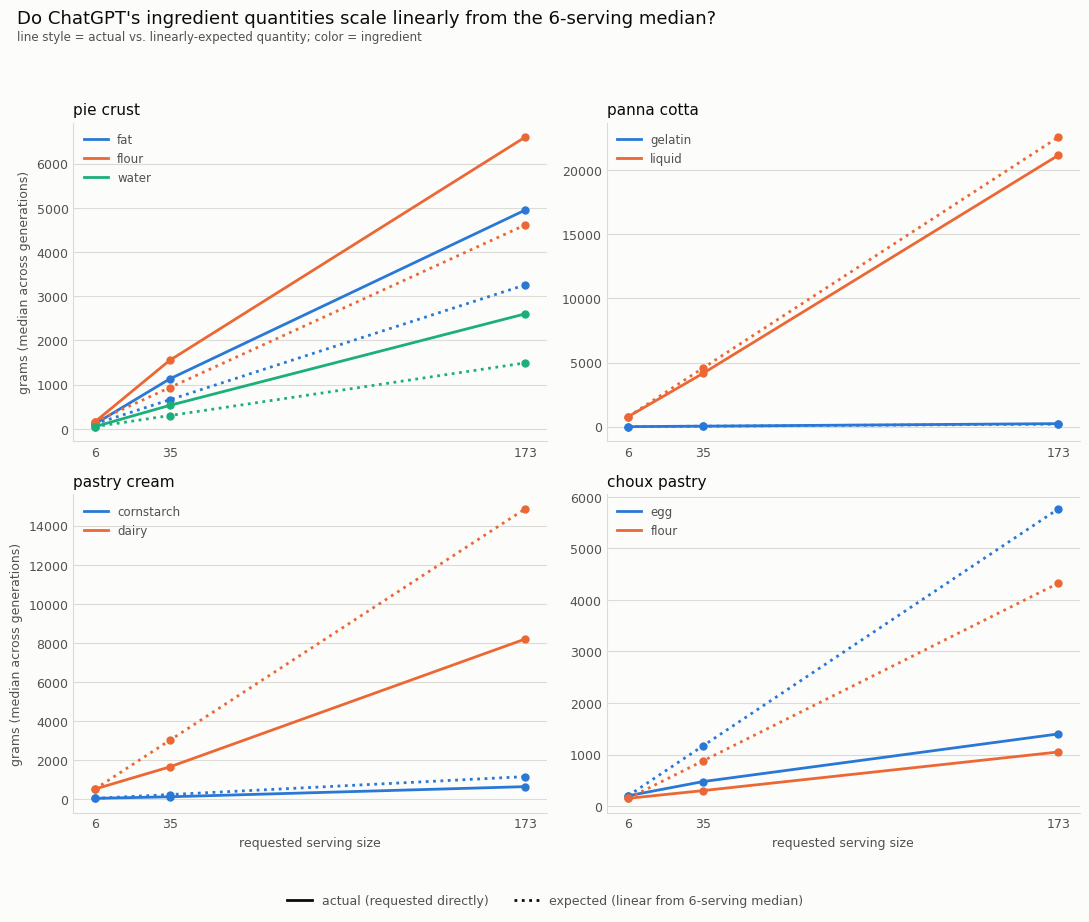

In [13]:
from matplotlib.lines import Line2D

INGREDIENT_PALETTE = ["#2a78d6", "#eb6834", "#1baf7a"]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
fig.patch.set_facecolor(BG)

for ax, recipe in zip(axes.flat, RECIPE_NAMES):
    style_axes(ax)
    ings = RECIPE_INGREDIENTS[recipe]
    ing_color = dict(zip(ings, INGREDIENT_PALETTE))
    for ing in ings:
        sub = median_by_scale[(median_by_scale["recipe"] == recipe) & (median_by_scale["ingredient"] == ing)]
        color = ing_color[ing]
        ax.plot(sub["scale_n"], sub["actual"], color=color, linestyle="-",
                 marker="o", linewidth=2, markersize=5)
        ax.plot(sub["scale_n"], sub["expected"], color=color, linestyle=":",
                 marker="o", linewidth=2, markersize=5)

    ax.set_xticks([6, 35, 173])
    ax.set_title(RECIPE_LABEL[recipe], color=INK, fontsize=11, loc="left")

    color_handles = [Line2D([0], [0], color=ing_color[ing], lw=2, label=ing) for ing in ings]
    ax.legend(handles=color_handles, loc="upper left", frameon=False,
              fontsize=8.5, labelcolor=INK_MUTED)

for ax in axes[:, 0]:
    ax.set_ylabel("grams (median across generations)", fontsize=9)
for ax in axes[-1]:
    ax.set_xlabel("requested serving size", fontsize=9)

style_handles = [
    Line2D([0, 1], [0, 0], color=INK, lw=2, linestyle="-", label="actual (requested directly)"),
    Line2D([0, 1], [0, 0], color=INK, lw=2, linestyle=":", label="expected (linear from 6-serving median)"),
]
fig.legend(handles=style_handles, loc="lower center", ncol=2, frameon=False,
           fontsize=9, labelcolor=INK_MUTED, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Do ChatGPT's ingredient quantities scale linearly from the 6-serving median?",
             color=INK, fontsize=13, x=0.02, y=0.99, ha="left")
fig.text(0.02, 0.955, "line style = actual vs. linearly-expected quantity; color = ingredient",
          color=INK_MUTED, fontsize=8.5, ha="left")
fig.tight_layout(rect=(0, 0.04, 1, 0.94))
plt.show()

In [14]:
# Same idea, but as a table: median actual vs. median-at-6-scaled-linearly,
# expressed as a % difference, one row per recipe/ingredient.
median_by_scale["pct_diff"] = (median_by_scale["actual"] / median_by_scale["expected"] - 1) * 100

pct_table = median_by_scale[median_by_scale["scale_n"] != 6].pivot(
    index=["recipe", "ingredient"], columns="scale", values="pct_diff")
pct_table = pct_table.loc[
    [(recipe, ing) for recipe in RECIPE_NAMES for ing in RECIPE_INGREDIENTS[recipe]],
    ["35", "173"],
]
pct_table.columns = ["% diff @ 35", "% diff @ 173"]
pct_table = pct_table.round(1).reset_index()
pct_table["recipe"] = pct_table["recipe"].apply(lambda x: x.replace("dough", "crust").replace("_", " ").title())
pct_table["ingredient"] = pct_table["ingredient"].apply(lambda x: x.replace("_", " ").title())
display(pct_table.rename({"recipe": "Recipe", "ingredient": "Ingredient"}, axis = 1).set_index("Recipe"))

| Recipe       | Ingredient   |   % diff @ 35 |   % diff @ 173 |
|:-------------|:-------------|--------------:|---------------:|
| Pie Crust    | Fat          |          71.4 |           51.9 |
| Pie Crust    | Flour        |          66.1 |           43.1 |
| Pie Crust    | Water        |          76.3 |           74.4 |
| Panna Cotta  | Gelatin      |          10.2 |           18.9 |
| Panna Cotta  | Liquid       |          -9.1 |           -6.3 |
| Pastry Cream | Cornstarch   |         -48.6 |          -44.5 |
| Pastry Cream | Dairy        |         -45.1 |          -44.8 |
| Choux        | Egg          |         -59.3 |          -75.7 |
| Choux        | Flour        |         -65.7 |          -75.7 |

It turns out that the LLM was wildly inaccurate in scaling recipes. It was fairly close for Panna Cotta, but for other recipes, the median LLM-scaled result was over 40% different from the result coming from multiplying the 6-person recipe. (Note that this could be a sign that the 6-person recipe is incorrect as well, but either way, it seems that there is a problem).

I'm fairly surprised that this type of linear scaling was so inaccurate in this context. It seems like this kind of task would be really low-hanging fruit for [Reinforcement Learning with Verifiable Rewards](https://arxiv.org/html/2503.06639v1) and you would think that OpenAI would prioritize making the "cooking with ChatGPT" experience better given their [usage guide](https://chatgpt.com/use-cases/recipes-cooking) advertising the functionality. But, I suppose that most people who set out to cook Choux Pastry for 173 people will probably triple-check the recipe before starting up their industrial mixer rather than using a one-shot recipe from ChatGPT.

# Conclusion

In the future, I'll probably continue to use an LLM for cooking (because I can taste and correct during the process) but for anything that seems like it could be messed up with bad ingredient ratios, I'll lean on a cookbook or human-tested recipe from a website. And, the next time I am cooking for 173 people, I will definitely scale linearly from a recipe I know works instead of generating a new one from scratch. We will just hope that if that every happens, I do not get too over-enthusiastic and also accidentally "scale the baking time" linearly as well.

Thanks for reading! And happy baking

